In [1]:
# Experiment 3 — Exploratory Data Analysis & Statistical Analysis

# Core data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical analysis
from scipy import stats

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

# Visualization style
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Load the validated processed dataset
DATA_PATH = "../data/processed/air_quality_cleaned.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print(f"Shape: {df.shape}")

Dataset loaded successfully.
Shape: (2763, 22)


In [3]:
# Display dataset structure and basic information

print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (2763, 22)

Column names:
['city', 'date', 'aqi', 'pm25', 'pm10', 'no2', 'so2', 'co', 'o3', 'year', 'month', 'day', 'day_of_week', 'day_of_year', 'is_weekend', 'aqi_lag_1', 'aqi_lag_3', 'aqi_lag_7', 'target_aqi', 'aqi_rolling_mean_3', 'aqi_rolling_mean_7', 'aqi_rolling_std_7']

Data types:
city                   object
date                   object
aqi                     int64
pm25                  float64
pm10                  float64
no2                   float64
so2                   float64
co                    float64
o3                    float64
year                    int64
month                   int64
day                     int64
day_of_week             int64
day_of_year             int64
is_weekend              int64
aqi_lag_1             float64
aqi_lag_3             float64
aqi_lag_7             float64
target_aqi            float64
aqi_rolling_mean_3    float64
aqi_rolling_mean_7    float64
aqi_rolling_std_7     float64
dtype: object

First 5 rows:


,city,date,aqi,pm25,pm10,no2,so2,co,o3,year,month,day,day_of_week,day_of_year,is_weekend,aqi_lag_1,aqi_lag_3,aqi_lag_7,target_aqi,aqi_rolling_mean_3,aqi_rolling_mean_7,aqi_rolling_std_7
0,Mumbai,2019-01-08,161,88.550,173.880,133.630,183.540,1.690,152.950,2019,1,8,1,8,0,146.000,178.000,194.000,154.000,172.000,197.143,38.429
1,Mumbai,2019-01-09,154,84.700,166.320,127.820,175.560,1.620,146.300,2019,1,9,2,9,0,161.000,192.000,180.000,219.000,166.333,192.429,40.828
2,Mumbai,2019-01-10,219,120.450,236.520,181.770,249.660,2.300,208.050,2019,1,10,3,10,0,154.000,146.000,267.000,212.000,153.667,188.714,43.258
3,Mumbai,2019-01-11,212,116.600,228.960,175.960,241.680,2.230,201.400,2019,1,11,4,11,0,219.000,161.000,223.000,200.000,178.000,181.857,30.787
4,Mumbai,2019-01-12,200,110.000,216.000,166.000,228.000,2.100,190.000,2019,1,12,5,12,1,212.000,154.000,178.000,206.000,195.000,180.286,28.535


In [4]:
# Verify the target column and data types

print("Number of columns:", len(df.columns))
print("\nTarget column present:", "target_aqi" in df.columns)

if "target_aqi" in df.columns:
    print("Target AQI preview:")
    print(df["target_aqi"].head())
else:
    print("WARNING: target_aqi is not present in the dataset.")

print("\nMissing values:")
print(df.isnull().sum().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Number of columns: 22

Target column present: True
Target AQI preview:
0   154.000
1   219.000
2   212.000
3   200.000
4   206.000
Name: target_aqi, dtype: float64

Missing values:
0

Duplicate rows:
0


In [5]:
# Descriptive statistics of numerical features

print("Descriptive Statistics:")
display(df.describe().T)

Descriptive Statistics:


,count,mean,std,min,25%,50%,75%,max
aqi,2763.000,106.995,56.693,9.000,61.000,90.000,148.500,381.000
pm25,2763.000,58.639,30.892,0.260,33.550,49.500,81.100,209.550
pm10,2763.000,114.416,61.131,0.000,64.660,97.060,157.680,411.480
no2,2763.000,87.990,46.493,8.690,50.410,74.700,121.180,316.230
so2,2763.000,120.812,64.095,0.000,68.400,102.600,166.440,434.340
co,2763.000,1.117,0.594,0.000,0.640,0.950,1.530,4.000
o3,2763.000,101.443,54.408,10.490,57.620,84.550,141.170,361.950
year,2763.000,2022.326,2.195,2019.000,2020.000,2022.000,2024.000,2026.000
month,2763.000,6.353,3.417,1.000,3.000,6.000,9.000,12.000
day,2763.000,15.733,8.791,1.000,8.000,16.000,23.000,31.000


In [6]:
# Create AQI categories for exploratory class/distribution analysis

def classify_aqi(aqi):
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Satisfactory"
    elif aqi <= 200:
        return "Moderate"
    elif aqi <= 300:
        return "Poor"
    elif aqi <= 400:
        return "Very Poor"
    else:
        return "Severe"

df["aqi_category"] = df["aqi"].apply(classify_aqi)

print("AQI Category Distribution:")
display(df["aqi_category"].value_counts())

AQI Category Distribution:


aqi_category
Satisfactory    1130
Moderate        1026
Good             403
Poor             203
Very Poor          1
Name: count, dtype: int64

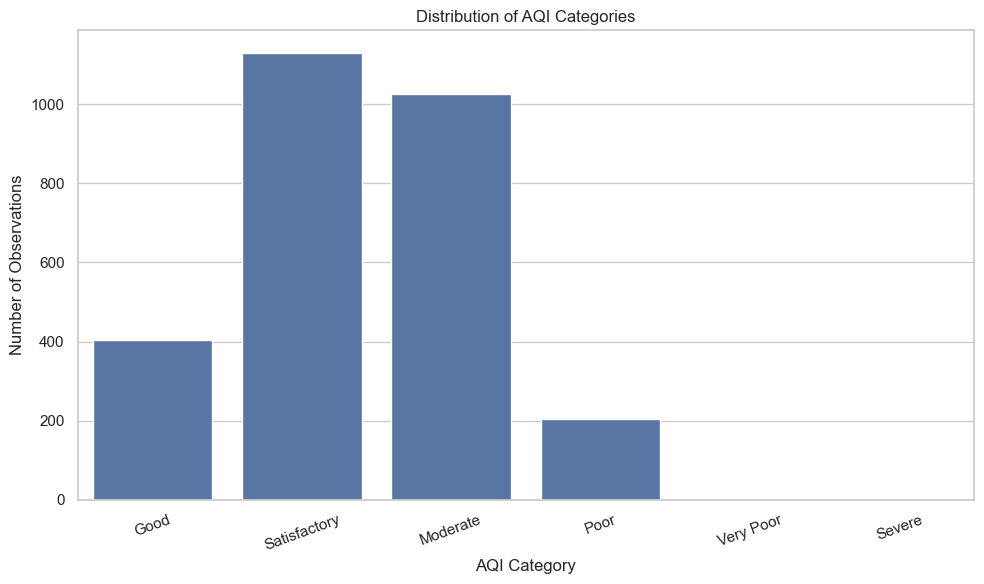

In [7]:
# Visualize the distribution of AQI categories

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="aqi_category",
    order=["Good", "Satisfactory", "Moderate", "Poor", "Very Poor", "Severe"]
)

plt.title("Distribution of AQI Categories")
plt.xlabel("AQI Category")
plt.ylabel("Number of Observations")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

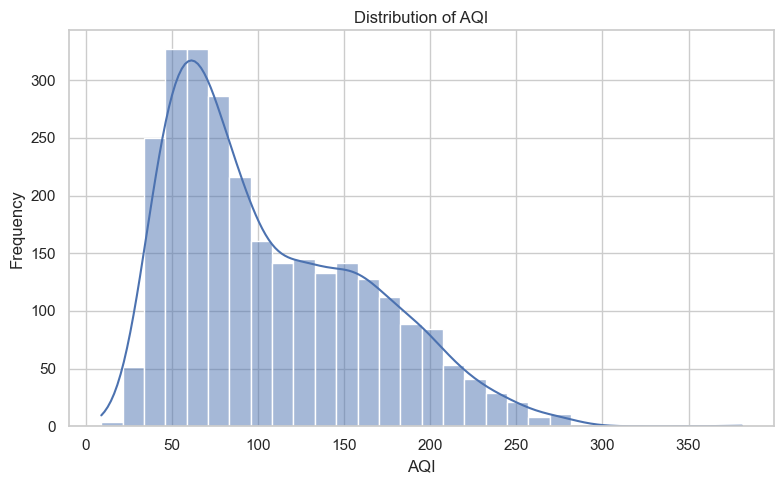

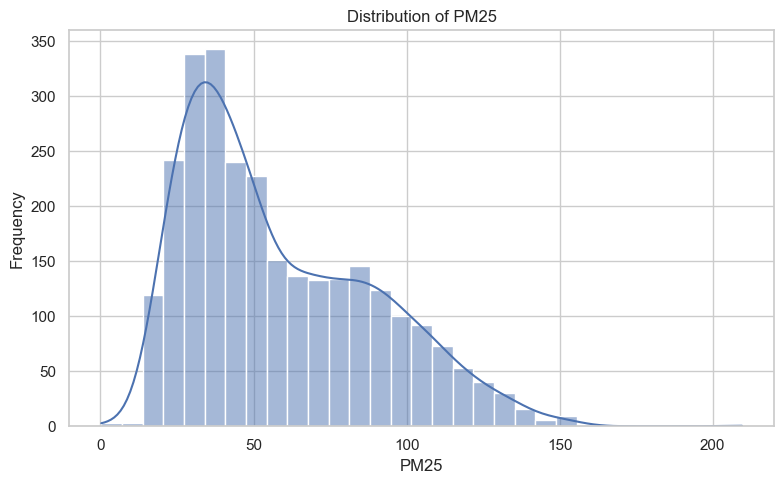

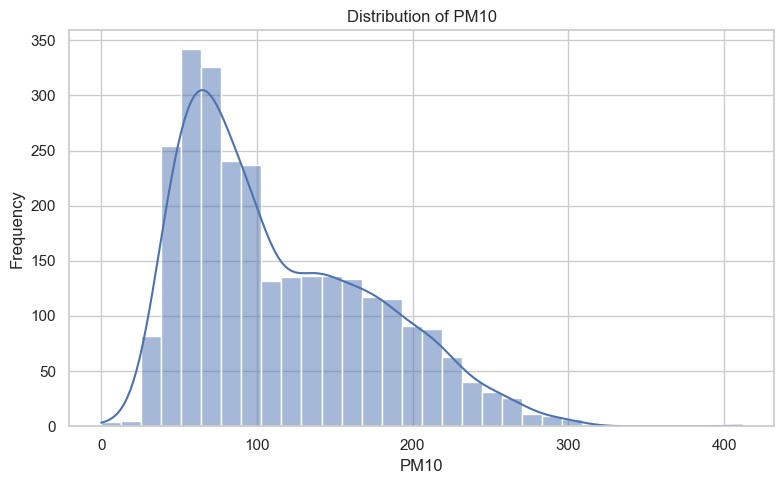

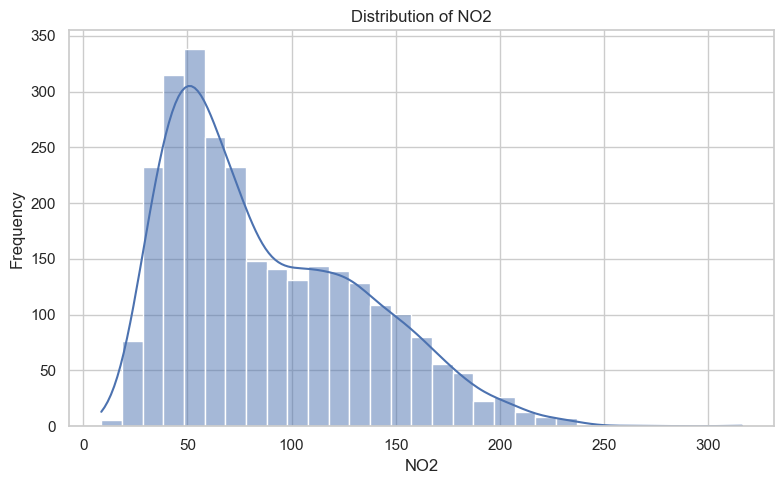

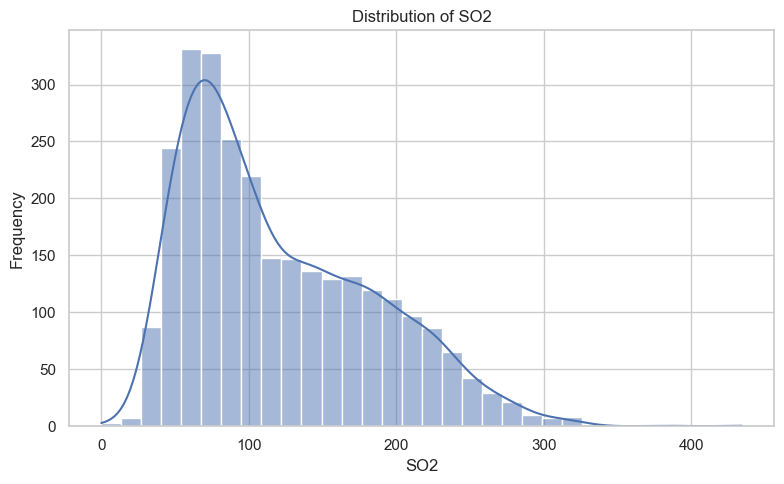

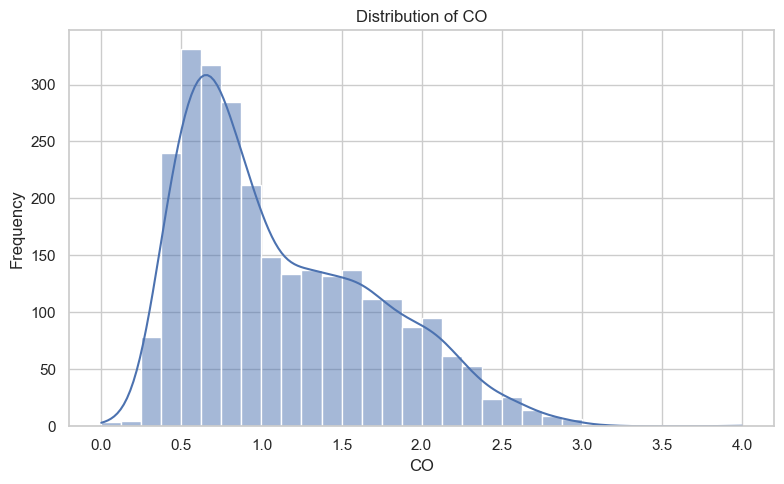

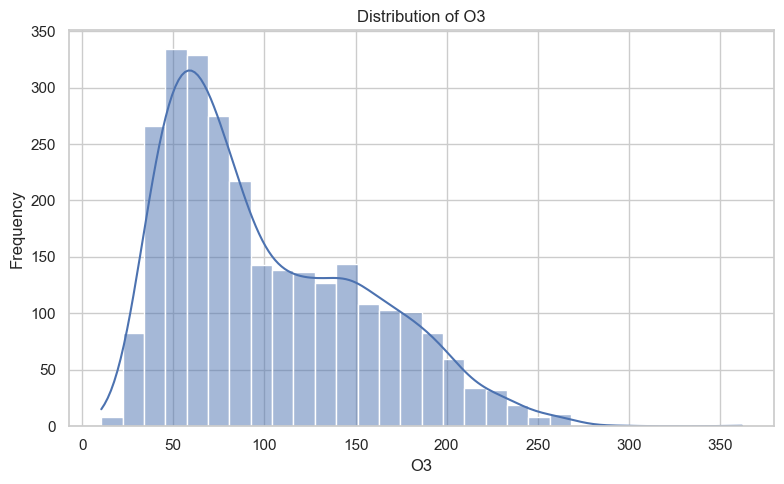

In [8]:
# Plot frequency distributions of major air-quality features

features = ["aqi", "pm25", "pm10", "no2", "so2", "co", "o3"]

for feature in features:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df, x=feature, kde=True)
    
    plt.title(f"Distribution of {feature.upper()}")
    plt.xlabel(feature.upper())
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

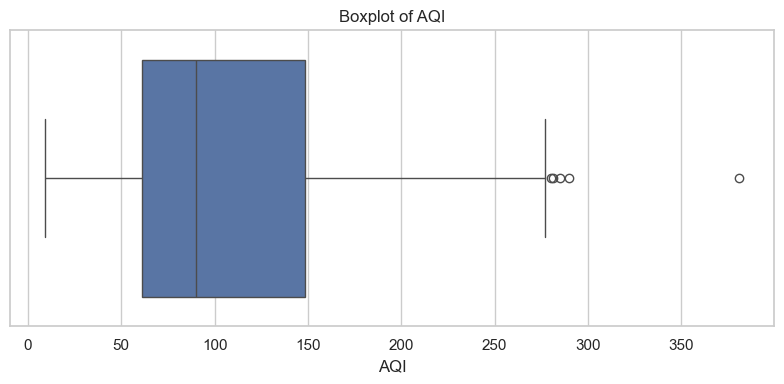

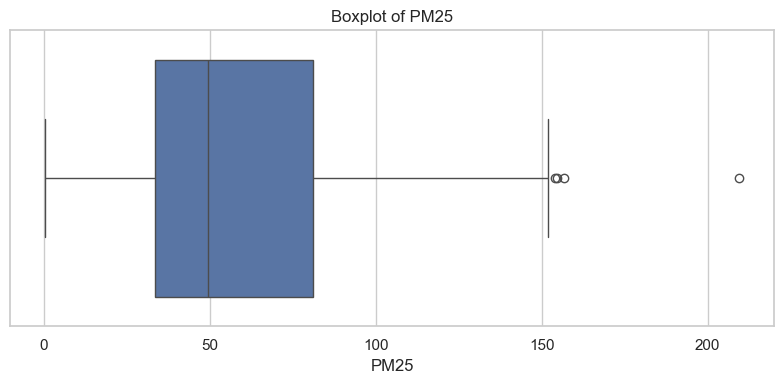

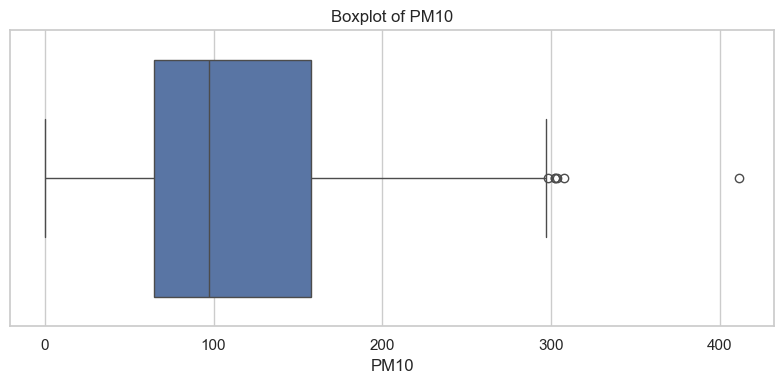

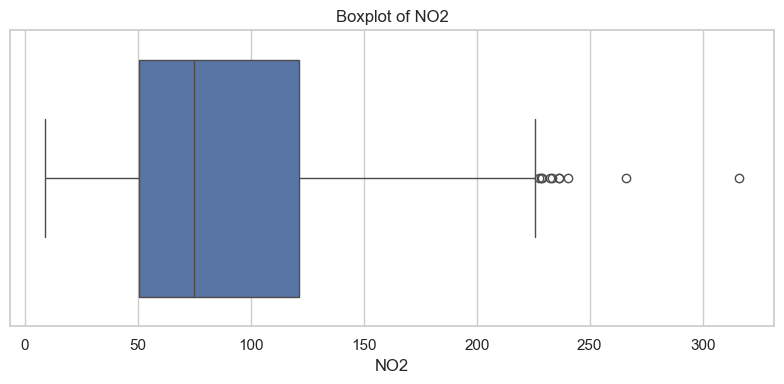

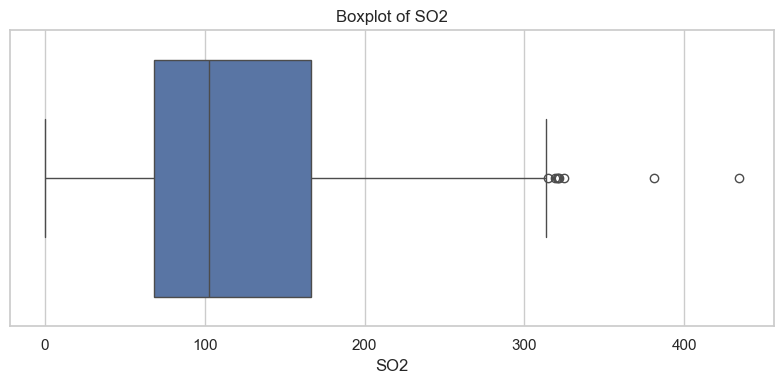

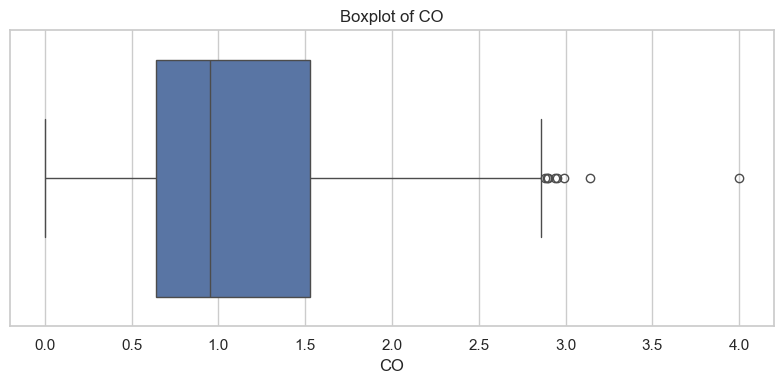

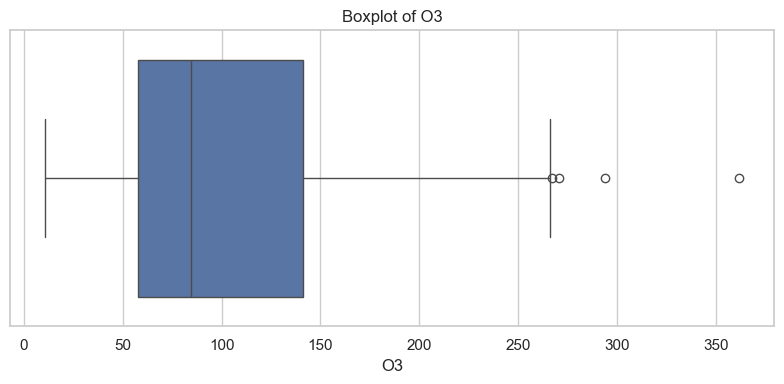

In [9]:
# Detect potential outliers using boxplots

for feature in features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x=feature)
    
    plt.title(f"Boxplot of {feature.upper()}")
    plt.xlabel(feature.upper())
    plt.tight_layout()
    plt.show()

In [10]:
# Calculate correlation matrix for numerical features

correlation_features = [
    "aqi",
    "pm25",
    "pm10",
    "no2",
    "so2",
    "co",
    "o3",
    "aqi_lag_1",
    "aqi_lag_3",
    "aqi_lag_7",
    "aqi_rolling_mean_3",
    "aqi_rolling_mean_7",
    "aqi_rolling_std_7",
    "target_aqi"
]

correlation_matrix = df[correlation_features].corr()

print("Correlation Matrix:")
display(correlation_matrix.round(2))

Correlation Matrix:


,aqi,pm25,pm10,no2,so2,co,o3,aqi_lag_1,aqi_lag_3,aqi_lag_7,aqi_rolling_mean_3,aqi_rolling_mean_7,aqi_rolling_std_7,target_aqi
aqi,1.000,0.940,0.930,0.930,0.930,0.920,0.920,0.850,0.760,0.730,0.850,0.840,0.560,0.850
pm25,0.940,1.000,0.920,0.940,0.920,0.930,0.920,0.850,0.760,0.730,0.850,0.840,0.540,0.860
pm10,0.930,0.920,1.000,0.920,0.930,0.930,0.920,0.850,0.760,0.730,0.850,0.840,0.540,0.850
no2,0.930,0.940,0.920,1.000,0.920,0.930,0.910,0.860,0.760,0.730,0.850,0.840,0.530,0.860
so2,0.930,0.920,0.930,0.920,1.000,0.930,0.920,0.850,0.750,0.730,0.850,0.840,0.540,0.860
co,0.920,0.930,0.930,0.930,0.930,1.000,0.920,0.850,0.760,0.730,0.850,0.840,0.540,0.850
o3,0.920,0.920,0.920,0.910,0.920,0.920,1.000,0.850,0.760,0.730,0.850,0.840,0.550,0.850
aqi_lag_1,0.850,0.850,0.850,0.860,0.850,0.850,0.850,1.000,0.790,0.730,0.940,0.890,0.580,0.790
aqi_lag_3,0.760,0.760,0.760,0.760,0.750,0.760,0.760,0.790,1.000,0.740,0.940,0.920,0.590,0.740
aqi_lag_7,0.730,0.730,0.730,0.730,0.730,0.730,0.730,0.730,0.740,1.000,0.780,0.890,0.600,0.730


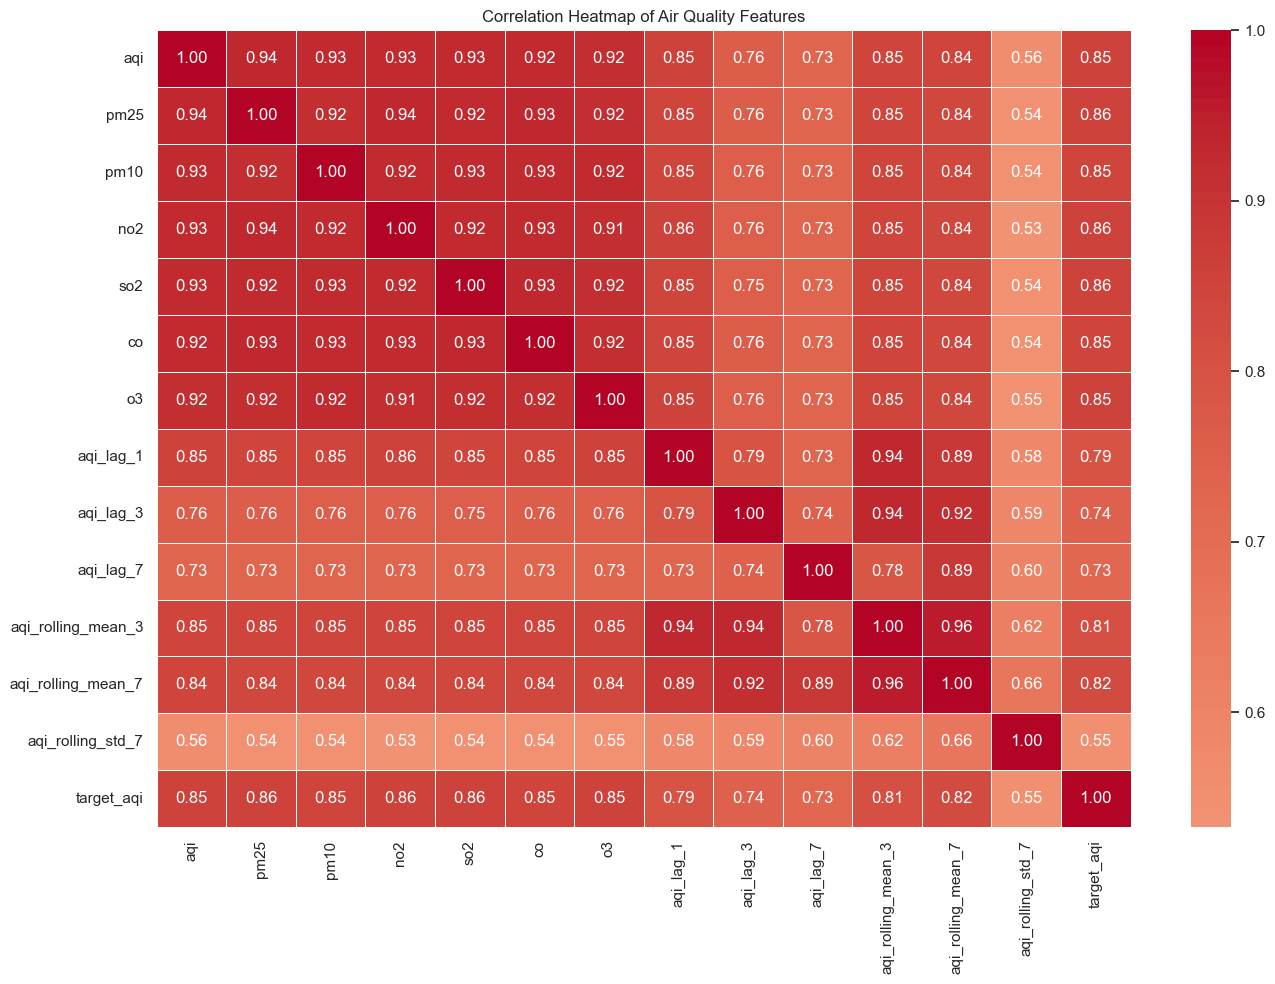

In [11]:
# Visualize feature correlations using a heatmap

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Heatmap of Air Quality Features")
plt.tight_layout()
plt.show()

In [12]:
# Analyze skewness of continuous air-quality variables

distribution_features = [
    "aqi",
    "pm25",
    "pm10",
    "no2",
    "so2",
    "co",
    "o3"
]

skewness = df[distribution_features].skew().sort_values(ascending=False)

print("Skewness of Air Quality Features:")
display(skewness.to_frame(name="skewness"))

Skewness of Air Quality Features:


,skewness
o3,0.781
no2,0.780
so2,0.775
co,0.773
aqi,0.768
pm10,0.767
pm25,0.763


In [13]:
# Identify potential outliers using the Interquartile Range (IQR) method

outlier_results = []

for feature in distribution_features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[feature] < lower_bound) |
        (df[feature] > upper_bound)
    ]

    outlier_results.append({
        "feature": feature,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": len(outliers),
        "outlier_percentage": (len(outliers) / len(df)) * 100
    })

outlier_summary = pd.DataFrame(outlier_results)

print("IQR-Based Outlier Analysis:")
display(outlier_summary.round(2))

IQR-Based Outlier Analysis:


,feature,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_percentage
0,aqi,61.000,148.500,87.500,-70.250,279.750,5,0.180
1,pm25,33.550,81.100,47.550,-37.770,152.420,4,0.140
2,pm10,64.660,157.680,93.020,-74.870,297.210,6,0.220
3,no2,50.410,121.180,70.770,-55.750,227.340,10,0.360
4,so2,68.400,166.440,98.040,-78.660,313.500,8,0.290
5,co,0.640,1.530,0.890,-0.700,2.860,8,0.290
6,o3,57.620,141.170,83.550,-67.710,266.500,4,0.140


In [14]:
# Separate AQI observations into weekday and weekend groups

weekday_aqi = df.loc[df["is_weekend"] == 0, "aqi"]
weekend_aqi = df.loc[df["is_weekend"] == 1, "aqi"]

print("Weekday observations:", len(weekday_aqi))
print("Weekend observations:", len(weekend_aqi))

print("\nMean AQI:")
print("Weekday:", weekday_aqi.mean())
print("Weekend:", weekend_aqi.mean())

Weekday observations: 1974
Weekend observations: 789

Mean AQI:
Weekday: 106.68642350557244
Weekend: 107.76679340937896


In [15]:
# Independent two-sample t-test
# H0: Mean weekday AQI = Mean weekend AQI
# H1: Mean weekday AQI != Mean weekend AQI

t_statistic, p_value = stats.ttest_ind(
    weekday_aqi,
    weekend_aqi,
    equal_var=False
)

alpha = 0.05

print("Independent Two-Sample T-Test")
print("--------------------------------")
print(f"t-statistic: {t_statistic:.4f}")
print(f"p-value: {p_value:.6f}")
print(f"Significance level (alpha): {alpha}")

if p_value < alpha:
    print("\nDecision: Reject the null hypothesis.")
    print("Conclusion: There is a statistically significant difference")
    print("between mean weekday and weekend AQI.")
else:
    print("\nDecision: Fail to reject the null hypothesis.")
    print("Conclusion: There is no statistically significant difference")
    print("between mean weekday and weekend AQI.")

Independent Two-Sample T-Test
--------------------------------
t-statistic: -0.4552
p-value: 0.649048
Significance level (alpha): 0.05

Decision: Fail to reject the null hypothesis.
Conclusion: There is no statistically significant difference
between mean weekday and weekend AQI.


In [16]:
# Summarize the hypothesis test results

hypothesis_result = pd.DataFrame({
    "Item": [
        "Null Hypothesis (H0)",
        "Alternative Hypothesis (H1)",
        "Weekday Mean AQI",
        "Weekend Mean AQI",
        "Test Statistic",
        "P-value",
        "Significance Level",
        "Decision"
    ],
    "Result": [
        "Mean weekday AQI = Mean weekend AQI",
        "Mean weekday AQI != Mean weekend AQI",
        f"{weekday_aqi.mean():.2f}",
        f"{weekend_aqi.mean():.2f}",
        f"{t_statistic:.4f}",
        f"{p_value:.6f}",
        f"{alpha}",
        "Reject H0" if p_value < alpha else "Fail to Reject H0"
    ]
})

display(hypothesis_result)

,Item,Result
0,Null Hypothesis (H0),Mean weekday AQI = Mean weekend AQI
1,Alternative Hypothesis (H1),Mean weekday AQI != Mean weekend AQI
2,Weekday Mean AQI,106.69
3,Weekend Mean AQI,107.77
4,Test Statistic,-0.4552
5,P-value,0.649048
6,Significance Level,0.05
7,Decision,Fail to Reject H0


In [17]:
# Generate key numerical insights for documentation

print("KEY EDA INSIGHTS")
print("=" * 50)

print(f"Total observations: {len(df)}")
print(f"AQI mean: {df['aqi'].mean():.2f}")
print(f"AQI median: {df['aqi'].median():.2f}")
print(f"AQI minimum: {df['aqi'].min():.2f}")
print(f"AQI maximum: {df['aqi'].max():.2f}")

print("\nStrongest correlations with target_aqi:")
target_correlations = (
    correlation_matrix["target_aqi"]
    .drop("target_aqi")
    .abs()
    .sort_values(ascending=False)
)

display(
    correlation_matrix.loc[
        target_correlations.index,
        "target_aqi"
    ].to_frame(name="correlation_with_target")
)

print("\nMost skewed features:")
display(skewness.head(3).to_frame(name="skewness"))

KEY EDA INSIGHTS
Total observations: 2763
AQI mean: 106.99
AQI median: 90.00
AQI minimum: 9.00
AQI maximum: 381.00

Strongest correlations with target_aqi:


,correlation_with_target
so2,0.857
pm25,0.857
no2,0.856
aqi,0.854
o3,0.853
pm10,0.851
co,0.850
aqi_rolling_mean_7,0.824
aqi_rolling_mean_3,0.811
aqi_lag_1,0.794



Most skewed features:


,skewness
o3,0.781
no2,0.780
so2,0.775


In [18]:
# Create broader AQI groups for statistical analysis
# Very Poor and Severe are combined with Poor because they have
# very few or no observations in the dataset.

def create_aqi_group(aqi):
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Satisfactory"
    elif aqi <= 200:
        return "Moderate"
    else:
        return "Poor+"

df["aqi_group"] = df["aqi"].apply(create_aqi_group)

print("AQI Group Distribution:")
display(df["aqi_group"].value_counts())

AQI Group Distribution:


aqi_group
Satisfactory    1130
Moderate        1026
Good             403
Poor+            204
Name: count, dtype: int64

In [19]:
# One-Way ANOVA
# H0: Mean pollutant concentration is the same across all AQI groups.
# H1: At least one AQI group has a different mean pollutant concentration.

pollutants = ["pm25", "pm10", "no2", "so2", "co", "o3"]

anova_results = []

for pollutant in pollutants:

    groups = [
        group[pollutant].dropna().values
        for _, group in df.groupby("aqi_group", observed=True)
    ]

    f_statistic, p_value = stats.f_oneway(*groups)

    anova_results.append({
        "Pollutant": pollutant.upper(),
        "F-statistic": f_statistic,
        "p-value": p_value,
        "Significant (p < 0.05)": "Yes" if p_value < 0.05 else "No"
    })

anova_results = pd.DataFrame(anova_results)

display(anova_results.round(6))

,Pollutant,F-statistic,p-value,Significant (p < 0.05)
0,PM25,3076.200,0.000,Yes
1,PM10,2737.511,0.000,Yes
2,NO2,2918.448,0.000,Yes
3,SO2,2832.752,0.000,Yes
4,CO,2745.674,0.000,Yes
5,O3,2709.450,0.000,Yes


In [20]:
# Interpret ANOVA results

alpha = 0.05

print("ANOVA Interpretation")
print("=" * 60)

for _, row in anova_results.iterrows():

    pollutant = row["Pollutant"]
    f_value = row["F-statistic"]
    p_value = row["p-value"]

    print(f"\n{pollutant}")
    print(f"F-statistic = {f_value:.4f}")
    print(f"P-value     = {p_value:.6f}")

    if p_value < alpha:
        print("Decision    = Reject H0")
        print(
            f"Conclusion  = Mean {pollutant} concentration "
            "differs significantly across AQI groups."
        )
    else:
        print("Decision    = Fail to Reject H0")
        print(
            f"Conclusion  = No statistically significant difference "
            f"in mean {pollutant} concentration across AQI groups."
        )

ANOVA Interpretation

PM25
F-statistic = 3076.2003
P-value     = 0.000000
Decision    = Reject H0
Conclusion  = Mean PM25 concentration differs significantly across AQI groups.

PM10
F-statistic = 2737.5107
P-value     = 0.000000
Decision    = Reject H0
Conclusion  = Mean PM10 concentration differs significantly across AQI groups.

NO2
F-statistic = 2918.4475
P-value     = 0.000000
Decision    = Reject H0
Conclusion  = Mean NO2 concentration differs significantly across AQI groups.

SO2
F-statistic = 2832.7520
P-value     = 0.000000
Decision    = Reject H0
Conclusion  = Mean SO2 concentration differs significantly across AQI groups.

CO
F-statistic = 2745.6743
P-value     = 0.000000
Decision    = Reject H0
Conclusion  = Mean CO concentration differs significantly across AQI groups.

O3
F-statistic = 2709.4503
P-value     = 0.000000
Decision    = Reject H0
Conclusion  = Mean O3 concentration differs significantly across AQI groups.


In [21]:
# Final ANOVA hypothesis-test summary

anova_summary = anova_results.copy()

anova_summary["Alpha"] = 0.05

anova_summary["Decision"] = anova_summary["p-value"].apply(
    lambda p: "Reject H0" if p < 0.05 else "Fail to Reject H0"
)

anova_summary["Interpretation"] = anova_summary["p-value"].apply(
    lambda p: "Significant difference between AQI groups"
    if p < 0.05
    else "No significant difference between AQI groups"
)

display(anova_summary.round(6))

,Pollutant,F-statistic,p-value,Significant (p < 0.05),Alpha,Decision,Interpretation
0,PM25,3076.200,0.000,Yes,0.050,Reject H0,Significant difference between AQI groups
1,PM10,2737.511,0.000,Yes,0.050,Reject H0,Significant difference between AQI groups
2,NO2,2918.448,0.000,Yes,0.050,Reject H0,Significant difference between AQI groups
3,SO2,2832.752,0.000,Yes,0.050,Reject H0,Significant difference between AQI groups
4,CO,2745.674,0.000,Yes,0.050,Reject H0,Significant difference between AQI groups
5,O3,2709.450,0.000,Yes,0.050,Reject H0,Significant difference between AQI groups


In [22]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [23]:
# Tukey HSD Post-Hoc Test
#
# ANOVA tells us whether at least one AQI group differs.
# Tukey HSD identifies which specific AQI groups differ.
#
# H0: The two compared AQI groups have equal pollutant means.
# H1: The two compared AQI groups have different pollutant means.

pollutants = ["pm25", "pm10", "no2", "so2", "co", "o3"]

tukey_results = {}

for pollutant in pollutants:

    tukey = pairwise_tukeyhsd(
        endog=df[pollutant],
        groups=df["aqi_group"],
        alpha=0.05
    )

    tukey_results[pollutant.upper()] = tukey

    print("=" * 80)
    print(f"Tukey HSD Results for {pollutant.upper()}")
    print("=" * 80)
    print(tukey)

Tukey HSD Results for PM25
     Multiple Comparison of Means - Tukey HSD, FWER=0.05     
 group1     group2    meandiff p-adj  lower    upper   reject
-------------------------------------------------------------
    Good     Moderate  55.0319   0.0   52.791  57.2727   True
    Good        Poor+  93.3352   0.0  90.0599  96.6105   True
    Good Satisfactory  15.3828   0.0  13.1712  17.5944   True
Moderate        Poor+  38.3034   0.0  35.3813  41.2254   True
Moderate Satisfactory -39.6491   0.0 -41.2929 -38.0053   True
   Poor+ Satisfactory -77.9524   0.0 -80.8521 -75.0528   True
-------------------------------------------------------------
Tukey HSD Results for PM10
      Multiple Comparison of Means - Tukey HSD, FWER=0.05       
 group1     group2     meandiff p-adj   lower     upper   reject
----------------------------------------------------------------
    Good     Moderate  107.0884   0.0  102.4532  111.7235   True
    Good        Poor+  182.5706   0.0  175.7957  189.3455   True
 

In [24]:
# Create a combined Tukey HSD summary

tukey_summary = []

for pollutant, tukey in tukey_results.items():

    results = pd.DataFrame(
        data=tukey._results_table.data[1:],
        columns=tukey._results_table.data[0]
    )

    results["Pollutant"] = pollutant

    tukey_summary.append(results)

tukey_summary = pd.concat(
    tukey_summary,
    ignore_index=True
)

display(tukey_summary)

,group1,group2,meandiff,p-adj,lower,upper,reject,Pollutant
0,Good,Moderate,55.032,0.000,52.791,57.273,True,PM25
1,Good,Poor+,93.335,0.000,90.060,96.611,True,PM25
2,Good,Satisfactory,15.383,0.000,13.171,17.594,True,PM25
3,Moderate,Poor+,38.303,0.000,35.381,41.225,True,PM25
4,Moderate,Satisfactory,-39.649,0.000,-41.293,-38.005,True,PM25
5,Poor+,Satisfactory,-77.952,0.000,-80.852,-75.053,True,PM25
6,Good,Moderate,107.088,0.000,102.453,111.724,True,PM10
7,Good,Poor+,182.571,0.000,175.796,189.345,True,PM10
8,Good,Satisfactory,29.968,0.000,25.393,34.543,True,PM10
9,Moderate,Poor+,75.482,0.000,69.438,81.526,True,PM10


In [25]:
# Interpret Tukey HSD results

print("Tukey HSD Interpretation")
print("=" * 80)

for pollutant, tukey in tukey_results.items():

    print(f"\n{pollutant}")

    results = pd.DataFrame(
        data=tukey._results_table.data[1:],
        columns=tukey._results_table.data[0]
    )

    for _, row in results.iterrows():

        group1 = row["group1"]
        group2 = row["group2"]
        p_value = float(row["p-adj"])
        reject = row["reject"]

        if reject:
            conclusion = "Significant difference"
        else:
            conclusion = "No significant difference"

        print(
            f"{group1} vs {group2}: "
            f"p = {p_value:.6f} → {conclusion}"
        )

Tukey HSD Interpretation

PM25
Good vs Moderate: p = 0.000000 → Significant difference
Good vs Poor+: p = 0.000000 → Significant difference
Good vs Satisfactory: p = 0.000000 → Significant difference
Moderate vs Poor+: p = 0.000000 → Significant difference
Moderate vs Satisfactory: p = 0.000000 → Significant difference
Poor+ vs Satisfactory: p = 0.000000 → Significant difference

PM10
Good vs Moderate: p = 0.000000 → Significant difference
Good vs Poor+: p = 0.000000 → Significant difference
Good vs Satisfactory: p = 0.000000 → Significant difference
Moderate vs Poor+: p = 0.000000 → Significant difference
Moderate vs Satisfactory: p = 0.000000 → Significant difference
Poor+ vs Satisfactory: p = 0.000000 → Significant difference

NO2
Good vs Moderate: p = 0.000000 → Significant difference
Good vs Poor+: p = 0.000000 → Significant difference
Good vs Satisfactory: p = 0.000000 → Significant difference
Moderate vs Poor+: p = 0.000000 → Significant difference
Moderate vs Satisfactory: p = 